In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
joosthazelzet_lego_brick_images_path = kagglehub.dataset_download('joosthazelzet/lego-brick-images')
print('Data source import complete.')


100%|██████████| 1.00G/1.00G [00:59<00:00, 18.1MB/s]

Extracting files...


Data source import complete.


# Install dependencies

In [ ]:
import numpy as np
import pandas as pd
import keras
from keras import layers
from keras import Sequential
from keras.layers import Dense, Activation,Dropout,Conv2D, MaxPooling2D,BatchNormalization
from keras.optimizers import Adam, Adamax
from keras.metrics import sparse_categorical_crossentropy
from keras import regularizers
from keras.models import Model
import tensorflow as tf
import os
import matplotlib.pyplot as plt
import shutil
import re
from pathlib import Path
from tqdm import tqdm

In [ ]:
print("TF version:", tf.__version__)
print("Keras version:", keras.__version__)
print("GPUs available:", tf.config.list_physical_devices('GPU'))

TF version: 2.19.0
Keras version: 3.13.2
GPUs available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# Load and prepare data

In [ ]:
## For bigger dataset

# src_dir = Path(joosthazelzet_lego_brick_images_path + "/dataset")
# ds_path = "dataset_organised"
# if os.path.isdir(ds_path) == False:
#   os.mkdir(ds_path)
# ds_path = Path(ds_path)

# skipped = 0
# copied = 0
# errors = 0

# for img_path in tqdm(src_dir.glob("*.png")):
#     filename = img_path.stem
#     match = re.match(r"^(.+?)\s+\d{3}[A-Z]?$", filename)

#     if not match:
#         print(f"[SKIP] Unrecognized pattern: {filename}")
#         skipped += 1
#         continue

#     class_name = match.group(1).strip()
#     class_dir = ds_path / class_name
#     class_dir.mkdir(parents=True, exist_ok=True)
#     dst_file = class_dir / img_path.name

#     if dst_file.exists():
#         skipped += 1
#         continue

#     try:
#         shutil.copy2(img_path, dst_file)
#         copied += 1
#     except Exception as e:
#         print(f"[ERROR] {img_path.name}: {e}")
#         errors += 1

# print(f"\nDone — copied: {copied}, skipped: {skipped}, errors: {errors}")
# ds_path = str(ds_path)

40000it [00:01, 24000.50it/s]


Done — copied: 0, skipped: 40000, errors: 0


In [ ]:
ds_path = joosthazelzet_lego_brick_images_path + "/LEGO brick images v1"

In [ ]:
image_size = (128, 128)
batch_size = 32
random_seed = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    directory = ds_path,
    validation_split=0.2,
    subset="training",
    seed=random_seed,
    image_size=image_size,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    directory = ds_path,
    validation_split=0.2,
    subset="validation",
    seed=random_seed,
    image_size=image_size,
    batch_size=batch_size
)

Found 6379 files belonging to 16 classes.
Using 5104 files for training.
Found 6379 files belonging to 16 classes.
Using 1275 files for validation.


In [ ]:
train_ds.class_names

['11214 Bush 3M friction with Cross axle',
 '18651 Cross Axle 2M with Snap friction',
 '2357 Brick corner 1x2x2',
 '3003 Brick 2x2',
 '3004 Brick 1x2',
 '3005 Brick 1x1',
 '3022 Plate 2x2',
 '3023 Plate 1x2',
 '3024 Plate 1x1',
 '3040 Roof Tile 1x2x45deg',
 '3069 Flat Tile 1x2',
 '32123 half Bush',
 '3673 Peg 2M',
 '3713 Bush for Cross Axle',
 '3794 Plate 1X2 with 1 Knob',
 '6632 Technic Lever 3M']

In [ ]:
class_count = 0
for cls in os.listdir(ds_path):
    class_count+=1
    count = 0
    for img in os.listdir(os.path.join(ds_path, cls)):
        if os.path.isfile(os.path.join(ds_path, cls, img)):
            count+=1
    print(f"Class {cls} has {count} images")
print(f"There are {class_count} classes")

Class 3022 Plate 2x2 has 400 images
Class 32123 half Bush has 400 images
Class 3004 Brick 1x2 has 400 images
Class 6632 Technic Lever 3M has 400 images
Class 3040 Roof Tile 1x2x45deg has 400 images
Class 3069 Flat Tile 1x2 has 400 images
Class 3673 Peg 2M has 400 images
Class 3713 Bush for Cross Axle has 400 images
Class 3023 Plate 1x2 has 400 images
Class 18651 Cross Axle 2M with Snap friction has 400 images
Class 3024 Plate 1x1 has 400 images
Class 3794 Plate 1X2 with 1 Knob has 400 images
Class 3003 Brick 2x2 has 400 images
Class 11214 Bush 3M friction with Cross axle has 400 images
Class 3005 Brick 1x1 has 400 images
Class 2357 Brick corner 1x2x2 has 379 images
There are 16 classes


In [ ]:
gen = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.056),
    layers.RandomTranslation(width_factor=0.2, height_factor=0.2),
    layers.RandomZoom(0.2)
])

In [ ]:
rescale = layers.Rescaling(1./255)

train_ds = train_ds.shuffle(1000).map(lambda x, y: (rescale(gen(x, training=True)), y)).cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (rescale(x), y)).cache().prefetch(buffer_size=tf.data.AUTOTUNE)

# Build a model

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=5,
        restore_best_weights=True
    ),

    keras.callbacks.ModelCheckpoint(
        filepath='best_model.keras',
        monitor='val_loss',
        save_best_only=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6
    )
]

In [ ]:
def make_model(img_size, lr = 0.001):
    base_model = keras.applications.MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_shape=(*image_size, 3),
        pooling='avg'
    )
    base_model.trainable=False
    x=base_model.output
    x=BatchNormalization(axis=-1, momentum=0.99, epsilon=0.001 )(x)
    x = Dense(256, kernel_regularizer = regularizers.l2(0.0001) ,activation='relu')(x)
    x=Dropout(rate=.4, seed=random_seed)(x)
    output=Dense(class_count, activation='softmax')(x)
    model=Model(inputs=base_model.input, outputs=output)
    model.compile(Adam(learning_rate=lr), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    return model

In [ ]:
model = make_model(image_size)

In [ ]:
history = model.fit(
    train_ds,
    epochs=30,
    callbacks=callbacks,
    validation_data=val_ds
)

Epoch 1/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 98s 408ms/step - accuracy: 0.6691 - loss: 1.0408 - val_accuracy: 0.6667 - val_loss: 0.9357 - learning_rate: 0.0010
Epoch 2/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8693 - loss: 0.4111 - val_accuracy: 0.7012 - val_loss: 0.8899 - learning_rate: 0.0010
Epoch 3/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - accuracy: 0.9246 - loss: 0.2660 - val_accuracy: 0.7365 - val_loss: 0.8712 - learning_rate: 0.0010
Epoch 4/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.9402 - loss: 0.2155 - val_accuracy: 0.7153 - val_loss: 0.9738 - learning_rate: 0.0010
Epoch 5/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9598 - loss: 0.1702 - val_accuracy: 0.7004 - val_loss: 1.1810 - learning_rate: 0.0010
Epoch 6/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9704 - loss: 0.1404 - val_accuracy: 0.7090 - val_loss: 1.1332 - learning_rate: 0.0010
Epoch 7/30
160/160 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9812 - loss: 

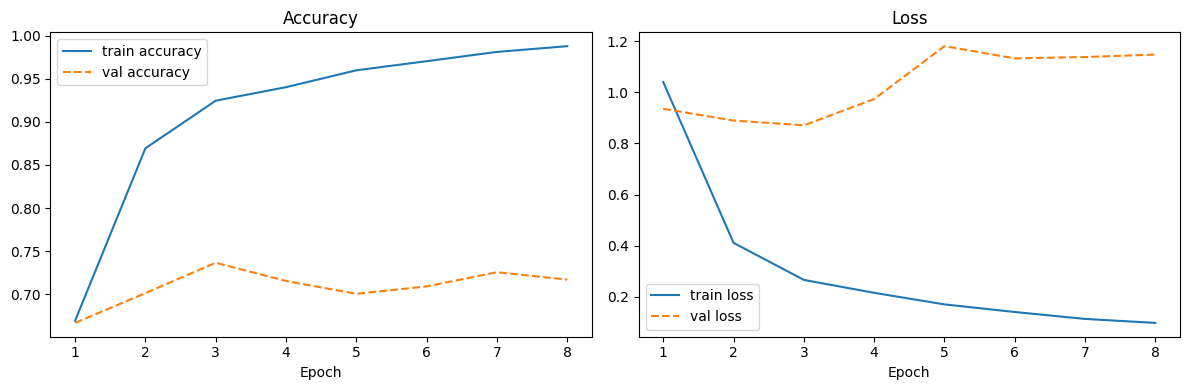

In [ ]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs, acc,     label='train accuracy')
ax1.plot(epochs, val_acc, label='val accuracy', linestyle='--')
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.legend()

ax2.plot(epochs, loss,     label='train loss')
ax2.plot(epochs, val_loss, label='val loss', linestyle='--')
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", 'wb') as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmp0zkwr0hg'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name='keras_tensor_5')
Output Type:
  TensorSpec(shape=(None, 16), dtype=tf.float32, name=None)
Captures:
  132844413792720: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132844413793872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132844413794064: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132844413793296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132844413791760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132844413793488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132844413795984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132844413792144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132844413795024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132844413792912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13284441379